# Hurricane Katrina — intensity timeline (2005)

Pull the North Atlantic best track around late August 2005, isolate Hurricane Katrina, and chart its wind and pressure over time. Point-mode query against the HURDAT2 reanalysis via the `tropycal` backend. See [Usage](../../reference/tropycal/usage.md).

In [1]:
from pathlib import Path

from earthlens import EarthLens

OUT_DIR = Path('tropycal_output')
OUT_DIR.mkdir(exist_ok=True)

In [2]:
# Live best-track query, wrapped so the notebook stays safe under nbval-lax
# when run offline / without the [tropycal] extra.
fixes = None
try:
    fixes = EarthLens(
        variables=['north_atlantic'],
        data_source='tropycal',
        start='2005-08-23',
        end='2005-08-31',
        lat_lim=[15.0, 35.0],
        lon_lim=[-95.0, -60.0],
        source='hurdat',
        path=str(OUT_DIR),
    ).download(progress_bar=False)
    print(len(fixes), 'fixes in window')
except Exception as exc:
    print(f'skipped live query: {type(exc).__name__}: {exc}')

2026-05-23 18:44:37 | INFO | pyramids.base.config | Logging is configured.


C:\python-environments\pixi\envs\earthlens-7782220113782294872\envs\dev\Lib\site-packages\tropycal\_version.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


2026-05-23 18:44:39.630 | INFO     | earthlens.tropycal.backend:_get_track_dataset:378 - Loading tropycal TrackDataset(basin='north_atlantic', source='hurdat'); the first load downloads + parses the whole basin best-track file and can be slow.


--> Starting to read in HURDAT2 data


--> Completed reading in HURDAT2 data (3.24 seconds)


2026-05-23 18:44:57 | INFO | pyogrio._io | Created 30 records


2026-05-23 18:44:57.174 | INFO     | earthlens.tropycal.backend:download:514 - Tropycal download summary: 30 feature(s) across 1 file(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\tropycal\docs\examples\tropycal\tropycal_output


30 fixes in window


In [3]:
if fixes is not None and len(fixes):
    katrina = fixes[fixes['name'] == 'KATRINA'].sort_values('time')
    peak = katrina.loc[katrina['vmax_kt'].idxmax()]
    print(
        f"Katrina: {len(katrina)} fixes, peak {peak['vmax_kt']:.0f} kt / "
        f"{peak['mslp_hpa']:.0f} hPa (cat {int(peak['category'])})"
    )

Katrina: 30 fixes, peak 150 kt / 902 hPa (cat 5)


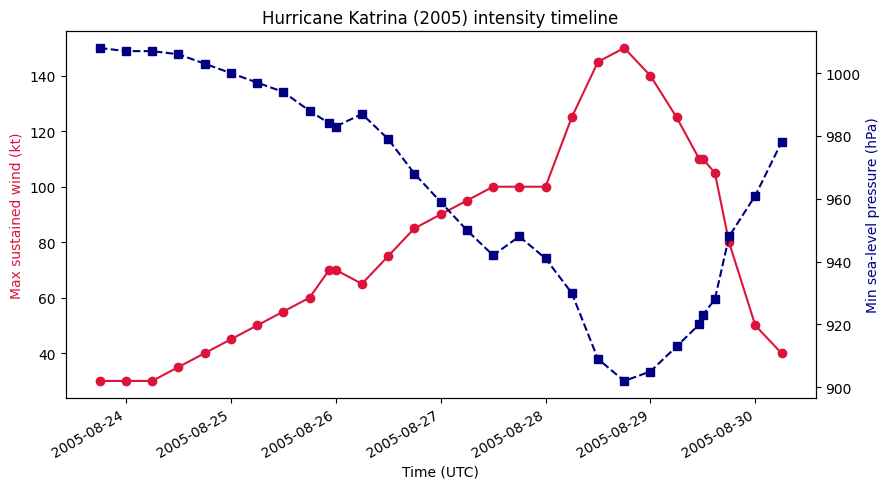

In [4]:
if fixes is not None and len(fixes):
    import matplotlib.pyplot as plt

    katrina = fixes[fixes['name'] == 'KATRINA'].sort_values('time')
    fig, ax1 = plt.subplots(figsize=(9, 5))
    ax1.plot(katrina['time'], katrina['vmax_kt'], 'o-', color='crimson')
    ax1.set_ylabel('Max sustained wind (kt)', color='crimson')
    ax2 = ax1.twinx()
    ax2.plot(katrina['time'], katrina['mslp_hpa'], 's--', color='navy')
    ax2.set_ylabel('Min sea-level pressure (hPa)', color='navy')
    ax1.set_title('Hurricane Katrina (2005) intensity timeline')
    ax1.set_xlabel('Time (UTC)')
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()